# 01 — Analyse exploratoire

**Question métier** : quels clients d'un opérateur télécom vont résilier, et pourquoi ?

Jeu de données : *Telco Customer Churn* (IBM), 7 043 clients, 1 ligne = 1 client, cible `Churn`
(a résilié le mois dernier). Objectif de ce notebook : comprendre les données, quantifier les liens
avec le churn **avec des tests statistiques** (et pas seulement des graphiques), et repérer les
pièges (valeurs manquantes, colinéarité, déséquilibre).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import FIGURES_DIR

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.4f}".format)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


In [2]:
from churn.data import CATEGORICAL_COLS, download, load

raw = pd.read_csv(download())
print(raw.shape)
raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


## 1. Qualité des données

In [3]:
blank_total = (raw["TotalCharges"].str.strip() == "").sum()
print(f"TotalCharges vides : {blank_total}")
print("tenure de ces clients :", raw.loc[raw["TotalCharges"].str.strip() == "", "tenure"].unique())
print("Doublons customerID :", raw["customerID"].duplicated().sum())

df = load()
df.isna().sum().sum()

TotalCharges vides : 11
tenure de ces clients : [0]
Doublons customerID : 0


np.int64(0)

Les 11 `TotalCharges` vides correspondent tous à `tenure = 0` : des clients arrivés ce mois-ci, qui
n'ont encore rien payé. On impute donc **0** (valeur exacte), pas la moyenne — ce nettoyage est
déterministe et ligne à ligne (`churn.data.clean`), donc sans fuite d'information.

## 2. Variable cible

Taux de churn : 26.5%  (IC95 Wilson [25.5% ; 27.6%])


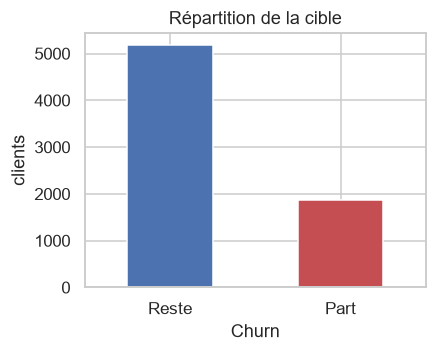

In [4]:
from statsmodels.stats.proportion import proportion_confint

n, k = len(df), df["Churn"].sum()
lo, hi = proportion_confint(k, n, method="wilson")
print(f"Taux de churn : {k / n:.1%}  (IC95 Wilson [{lo:.1%} ; {hi:.1%}])")

fig, ax = plt.subplots(figsize=(4, 3))
df["Churn"].map({0: "Reste", 1: "Part"}).value_counts().plot.bar(ax=ax, rot=0, color=["#4C72B0", "#C44E52"])
ax.set_title("Répartition de la cible"); ax.set_ylabel("clients")
save(fig, "01_target")

Classes déséquilibrées (~1 client sur 4 part) : l'*accuracy* serait trompeuse (73 % en prédisant
« reste » pour tout le monde). On suivra la **PR-AUC** (sensible à la classe minoritaire), la
ROC-AUC et le score de Brier (qualité des probabilités).

## 3. Variables numériques

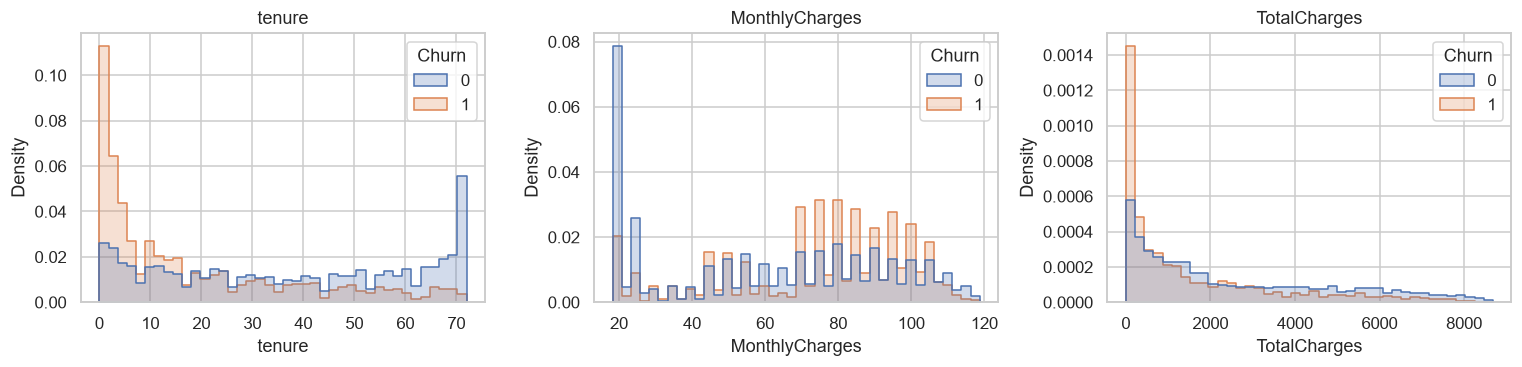

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", stat="density", common_norm=False,
                 element="step", bins=40, ax=ax)
    ax.set_title(col)
fig.tight_layout()
save(fig, "01_numeric_distributions")

In [6]:
from scipy.stats import mannwhitneyu

rows = []
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    a, b = df.loc[df.Churn == 1, col], df.loc[df.Churn == 0, col]
    u, p = mannwhitneyu(a, b)
    rows.append({
        "variable": col,
        "médiane churners": a.median(),
        "médiane fidèles": b.median(),
        "p-value": p,
        # Corrélation rang-bisériale : taille d'effet dans [-1, 1]
        "effet (rang-bisérial)": 1 - 2 * u / (len(a) * len(b)),
    })
pd.DataFrame(rows).set_index("variable")

,médiane churners,médiane fidèles,p-value,effet (rang-bisérial)
variable,,,,
tenure,10.0000,38.0000,0.0000,0.4797
MonthlyCharges,79.6500,64.4250,0.0000,-0.2416
TotalCharges,703.5500,1679.5250,0.0000,0.3007


Test de Mann-Whitney (non paramétrique : les distributions sont loin d'être normales).
Les churners ont une **ancienneté beaucoup plus faible** et une **facture mensuelle plus élevée** ;
`TotalCharges` ≈ `tenure × MonthlyCharges` porte surtout l'information d'ancienneté.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

num = add_constant(df[["tenure", "MonthlyCharges", "TotalCharges"]])
vif = pd.Series([variance_inflation_factor(num.values, i) for i in range(1, num.shape[1])],
                index=num.columns[1:], name="VIF")
print(vif.round(2))
print("\nCorrélation de Spearman :")
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(method="spearman").round(2)

tenure           5.8400
MonthlyCharges   3.2200
TotalCharges     9.5100
Name: VIF, dtype: float64

Corrélation de Spearman :


,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.0000,0.2800,0.8900,-0.3700
MonthlyCharges,0.2800,1.0000,0.6400,0.1800
TotalCharges,0.8900,0.6400,1.0000,-0.2300
Churn,-0.3700,0.1800,-0.2300,1.0000


VIF élevé pour `TotalCharges` : forte colinéarité avec `tenure` × `MonthlyCharges`. Sans gravité
pour les arbres, mais cela rend les coefficients d'une régression logistique instables — d'où la
régularisation L2 et une lecture prudente des *odds ratios*.

## 4. Variables catégorielles

In [8]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

def cramers_v(table):
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

rows = []
for col in CATEGORICAL_COLS + ["SeniorCitizen"]:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = chi2_contingency(table)
    rows.append({"variable": col, "chi2": chi2, "ddl": dof, "p": p, "V de Cramér": cramers_v(table)})

tests = pd.DataFrame(rows)
tests["p (Holm)"] = multipletests(tests["p"], method="holm")[1]
tests["significatif"] = tests["p (Holm)"] < 0.05
tests.sort_values("V de Cramér", ascending=False).set_index("variable")

,chi2,ddl,p,V de Cramér,p (Holm),significatif
variable,,,,,,
Contract,1184.5966,2,0.0000,0.4101,0.0000,True
OnlineSecurity,849.9990,2,0.0000,0.3474,0.0000,True
TechSupport,828.1971,2,0.0000,0.3429,0.0000,True
InternetService,732.3096,2,0.0000,0.3225,0.0000,True
PaymentMethod,648.1423,3,0.0000,0.3034,0.0000,True
OnlineBackup,601.8128,2,0.0000,0.2923,0.0000,True
DeviceProtection,558.4194,2,0.0000,0.2816,0.0000,True
StreamingMovies,375.6615,2,0.0000,0.2310,0.0000,True
StreamingTV,374.2039,2,0.0000,0.2305,0.0000,True


Test du χ² d'indépendance avec **correction de Holm** (16 tests simultanés → contrôle du risque de
faux positif global) et **V de Cramér** comme taille d'effet (une p-value minuscule sur 7 000 lignes
ne dit rien de l'ampleur). Le type de contrat, l'absence de sécurité en ligne / support technique,
la fibre et le paiement par chèque électronique dominent. Le **genre** et la présence du service
téléphonique n'ont pas d'effet détectable.

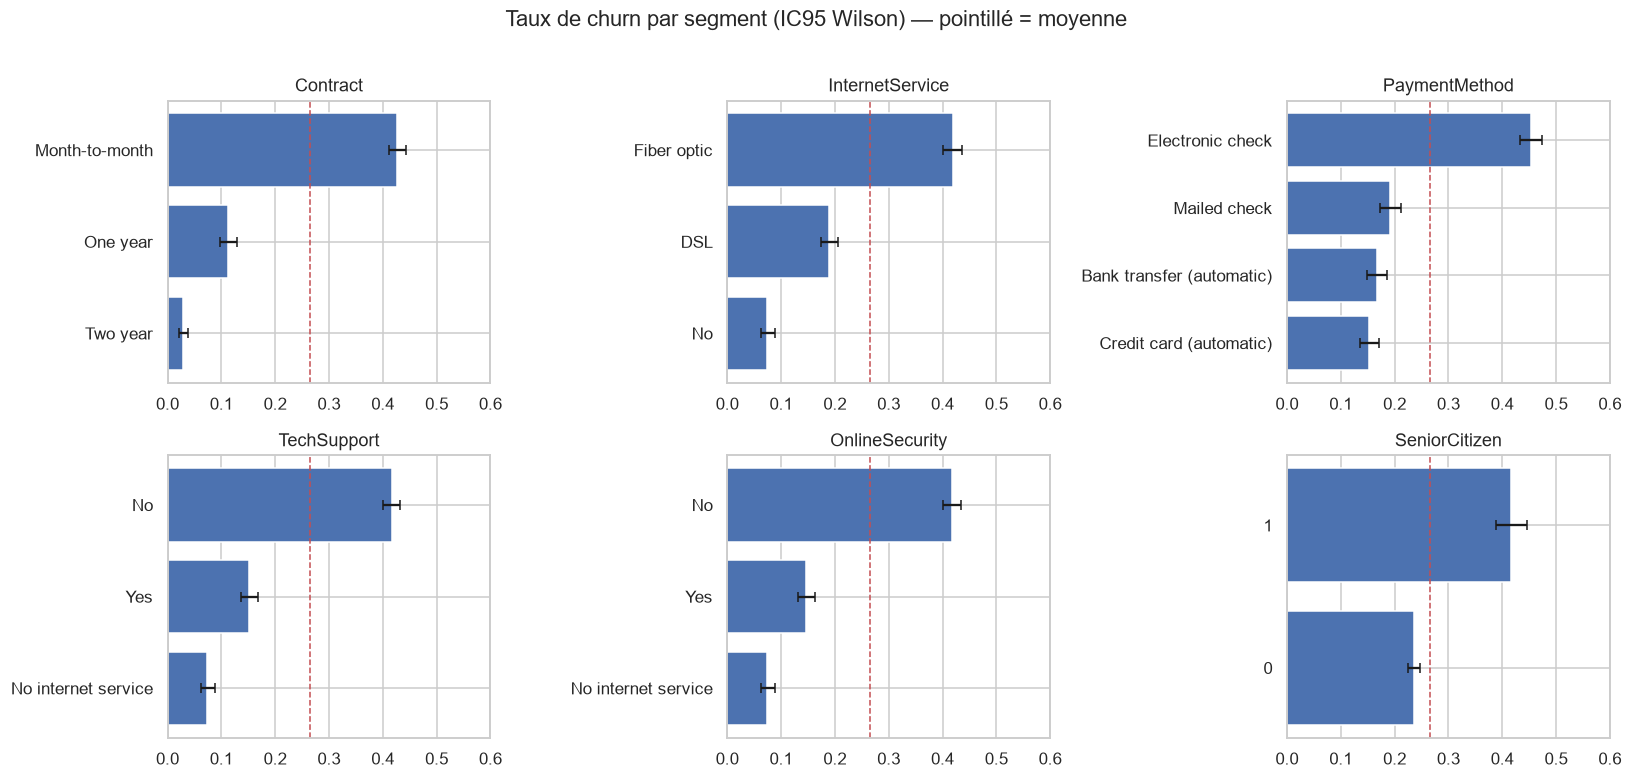

In [9]:
def churn_rate_ci(col):
    g = df.groupby(col)["Churn"].agg(["sum", "count"])
    ci = proportion_confint(g["sum"], g["count"], method="wilson")
    return pd.DataFrame({"taux": g["sum"] / g["count"], "lo": ci[0], "hi": ci[1], "n": g["count"]})

cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "SeniorCitizen"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
base = df["Churn"].mean()
for ax, col in zip(axes.ravel(), cols):
    r = churn_rate_ci(col).sort_values("taux")
    ax.barh(r.index.astype(str), r["taux"], xerr=[r["taux"] - r["lo"], r["hi"] - r["taux"]],
            color="#4C72B0", capsize=3)
    ax.axvline(base, color="#C44E52", ls="--", lw=1)
    ax.set_title(col); ax.set_xlim(0, 0.6)
fig.suptitle("Taux de churn par segment (IC95 Wilson) — pointillé = moyenne", y=1.01)
fig.tight_layout()
save(fig, "01_churn_by_segment")

## 5. Survie : quand les clients partent-ils ?

`tenure` est une durée et `Churn` un événement : on peut estimer une **courbe de Kaplan-Meier**
(les clients encore présents sont des observations *censurées*). Implémentation directe pour rester
transparent.

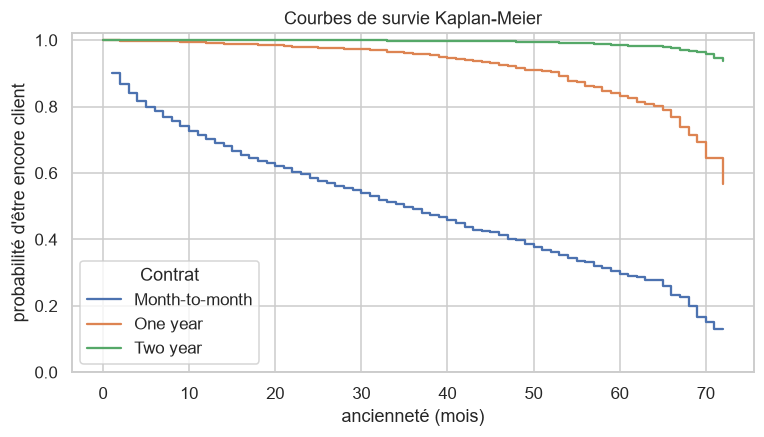

In [10]:
def kaplan_meier(durations, events):
    d = pd.DataFrame({"t": durations, "e": events})
    table = d.groupby("t").agg(deaths=("e", "sum"), n=("e", "size")).sort_index()
    table["at_risk"] = table["n"][::-1].cumsum()[::-1]
    table["S"] = (1 - table["deaths"] / table["at_risk"]).cumprod()
    return table["S"]

fig, ax = plt.subplots(figsize=(8, 4))
for contract, g in df.groupby("Contract"):
    s = kaplan_meier(g["tenure"], g["Churn"])
    ax.step(s.index, s.values, where="post", label=contract)
ax.set_xlabel("ancienneté (mois)"); ax.set_ylabel("probabilité d'être encore client")
ax.set_ylim(0, 1.02); ax.legend(title="Contrat"); ax.set_title("Courbes de survie Kaplan-Meier")
save(fig, "01_kaplan_meier")

In [11]:
from statsmodels.duration.survfunc import survdiff

stat, p = survdiff(df["tenure"], df["Churn"], df["Contract"])
print(f"Test du log-rank entre contrats : chi2 = {stat:.1f}, p = {p:.2e}")

Test du log-rank entre contrats : chi2 = 2352.9, p = 0.00e+00


Les clients *Month-to-month* partent massivement dans les **premiers mois** ; les contrats de 1 et
2 ans ont une survie très élevée (test du log-rank très significatif). Conséquence métier : les
actions de rétention ont le plus de valeur tôt dans la relation client.

## Conclusions pour la modélisation

1. Déséquilibre ~26,5 % → métriques PR-AUC / ROC-AUC / Brier et calibration des probabilités.
2. Signaux forts : contrat, ancienneté, fibre, services de protection, mode de paiement.
3. Colinéarité `TotalCharges` / `tenure` → régularisation, et variables dérivées plus
   informatives (tarif moyen historique, hausse de facture).
4. `gender` n'apporte rien : conservé (le modèle régularisé l'ignore) mais à surveiller pour
   l'équité.